# Demo of using the results of cityseg

This notebook briefly shows how to load and use the results of the CitySeg segmentation. The segmentation mask results are stored in an hdf5 file, which can be manipulated using the provided CitySegData class. Below, we display the segmentation mask and check its shape.

1. Load the CitySeg segmentation data from the hdf5 file. 


In [ ]:
# Import the CitySegData class for loading and working with segmentation data 
from ivr_utils.cityseg_utils import CitySegData
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load CitySeg segmentation data
cityseg_test = Path(
    "/Users/yuqiliang/Documents/Github/data/P17_merged_segmentation.h5"
)
# Define the path to the merged segmentation file.
cityseg_data = CitySegData.from_hdf(cityseg_test)
gaze_data_path = Path(
    "/Users/yuqiliang/Documents/Github/data/video_processing/P48/P48_chopped_fixedfps_modified.npy"
)
# Load gaze-tracking data
gaze_data = np.load(gaze_data_path)  


2. Compute the percentage of each segmentation mask class within the gaze region for every frame.

In [ ]:
percentages = cityseg_data.calculate_percentage_of_mask(gaze_data)

3. Merge the computed percentages with circumplex data from an Excel file and save the merged results to a new file.

In [ ]:
# set path to circumplex data
circumplex_path = Path("/Users/yuqiliang/Documents/UCLPhD/Eye-tracking/2024-08-29_14-20_circumplex_data.xlsx")

# set participant ID and output file path
PARTICIPANT = "P48"

# set output file path
output_file = Path("/Users/yuqiliang/Documents/Github/data/cityseg_test/autoresume_test_05/P48/merged_circumplex_P48.csv")

# Merge percentages with circumplex data and save to output file
merge_circumplex = cityseg_data.merge_percentage_with_circumplex(circumplex_path, percentages, PARTICIPANT, output_file)
print(merge_circumplex)

## Other functionalities

In [ ]:
# match gaze data with segmentation masks
matched_data = cityseg_data.match_gaze_with_masks(gaze_data, None)

In [ ]:
# Access the underlying HDF5 file if needed
cityseg_data.hdf_file

<HDF5 file "merged_segmentation.h5" (mode r)>

In [ ]:
#check the labels
label_ids = cityseg_data.metadata.get("label_ids", {})
print(label_ids)

{'0': 'road', '1': 'sidewalk', '2': 'building', '3': 'wall', '4': 'fence', '5': 'pole', '6': 'traffic light', '7': 'traffic sign', '8': 'vegetation', '9': 'terrain', '10': 'sky', '11': 'person', '12': 'rider', '13': 'car', '14': 'truck', '15': 'bus', '16': 'train', '17': 'motorcycle', '18': 'bicycle'}


In [ ]:
# Get the segmentation mask
seg_mask = cityseg_data.get_segmentation_mask()

In [ ]:
output_video = Path("/Users/yuqiliang/Documents/Github/data/cityseg_mp4_output/citseg_output_P17.mp4")
cityseg_data.export_segmentation_video(output_video)

[INFO] Segmentation video saved to: /Users/yuqiliang/Documents/Github/data/cityseg_mp4_output/citseg_output_P17.mp4


In [ ]:
print(seg_mask[0])

[[2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
# the shape of the segmentation mask
seg_mask.shape
# n frames, n rows, n cols

(5530, 2160, 3840)

In [ ]:
# the color palette used for visualization
cityseg_data.palette.shape
# n classes, rgb values

(20, 3)

In [ ]:
# the metadata dictionary
cityseg_data.metadata

{'model_name': 'facebook/mask2former-swin-large-cityscapes-semantic',
 'original_video': 'P48_chopped_fixedfps_1third.mp4',
 'palette': array([[128,  64, 128],
        [244,  35, 232],
        [ 70,  70,  70],
        [102, 102, 156],
        [190, 153, 153],
        [153, 153, 153],
        [250, 170,  30],
        [220, 220,   0],
        [107, 142,  35],
        [152, 251, 152],
        [ 70, 130, 180],
        [220,  20,  60],
        [255,   0,   0],
        [  0,   0, 142],
        [  0,   0,  70],
        [  0,  60, 100],
        [  0,  80, 100],
        [  0,   0, 230],
        [119,  11,  32],
        [  0,   0,   0]], dtype=uint8),
 'label_ids': {'0': 'road',
  '1': 'sidewalk',
  '2': 'building',
  '3': 'wall',
  '4': 'fence',
  '5': 'pole',
  '6': 'traffic light',
  '7': 'traffic sign',
  '8': 'vegetation',
  '9': 'terrain',
  '10': 'sky',
  '11': 'person',
  '12': 'rider',
  '13': 'car',
  '14': 'truck',
  '15': 'bus',
  '16': 'train',
  '17': 'motorcycle',
  '18': 'bicycle

In [ ]:
seg_mask[0]

array([[2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2160, 3840), dtype=int32)

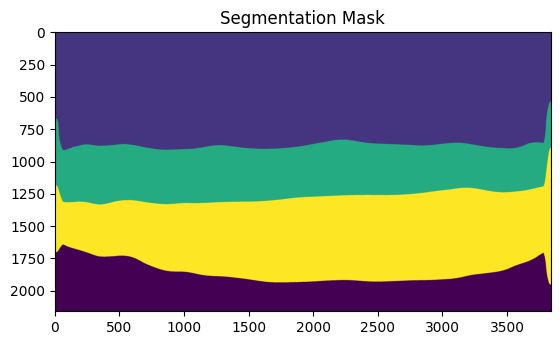

In [ ]:
# Display the segmentation mask
plt.imshow(seg_mask[0])
plt.title("Segmentation Mask")
plt.axis("on")
plt.show()


Read h5 file and display segmentation mask


In [ ]:
import h5py
import numpy as np

def read_h5_file(filepath):
    """
    Read an HDF5 file and print its structure and contents

    Args:
        filepath: Path to the HDF5 file
    """
    try:
        # Open the HDF5 file
        with h5py.File(filepath, 'r') as f:
            print(f"Successfully opened file: {filepath}\n")
            
            # Recursive function to traverse the file structure
            def print_structure(name, obj):
                if isinstance(obj, h5py.Dataset):
                    print(f"Dataset: {name}")
                    print(f"  - Shape: {obj.shape}")
                    print(f"  - Data type: {obj.dtype}")
                    print(f"  - Size: {obj.size}")
                    # If the dataset is not too large, print part of the data
                    if obj.size < 100:
                        print(f"  - Data: {obj[...]}")
                    print()
                elif isinstance(obj, h5py.Group):
                    print(f"Group: {name}")
            
            # Traverse all objects in the file
            print("=" * 50)
            print("File structure:")
            print("=" * 50)
            f.visititems(print_structure)
            
    except FileNotFoundError:
        print(f"Error: File not found {filepath}")
    except Exception as e:
        print(f"Error reading file: {e}")


def read_specific_dataset(filepath, dataset_name):
    """
    Read a specific dataset from an HDF5 file

    Args:
        filepath: Path to the HDF5 file
        dataset_name: Name or path of the dataset

    Returns:
        numpy array
    """
    with h5py.File(filepath, 'r') as f:
        if dataset_name in f:
            data = f[dataset_name][...]
            print(f"Successfully read dataset: {dataset_name}")
            print(f"Shape: {data.shape}, Type: {data.dtype}")
            return data
        else:
            print(f"Error: Dataset '{dataset_name}' not found")
            print(f"Available datasets: {list(f.keys())}")
            return None


# Example usage
if __name__ == "__main__":
    # Your HDF5 file path
    file_path = "/Users/yuqiliang/Documents/Github/data/cityseg_test/autoresume_test_04/P48_chopped_fixedfps_1third_mask2former-swin-large-cityscapes-semantic_step1_segmentation.h5"
    
    # Read and display file structure
    read_h5_file(file_path)
    
    # If you want to read a specific dataset, first run the above code to see available datasets,
    # then uncomment below and replace "dataset_name"
    # data = read_specific_dataset(file_path, "dataset_name")

Successfully opened file: /Users/yuqiliang/Documents/Github/data/autoresume_test_02_remaining_iter1/remaining_iter1_mask2former-swin-large-cityscapes-semantic_step1_segmentation.h5

File structure:
Dataset: metadata
  - Shape: ()
  - Data type: object
  - Size: 1
  - Data: b'{"model_name": "facebook/mask2former-swin-large-cityscapes-semantic", "original_video": "remaining_iter1.mp4", "palette": [[128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156], [190, 153, 153], [153, 153, 153], [250, 170, 30], [220, 220, 0], [107, 142, 35], [152, 251, 152], [70, 130, 180], [220, 20, 60], [255, 0, 0], [0, 0, 142], [0, 0, 70], [0, 60, 100], [0, 80, 100], [0, 0, 230], [119, 11, 32], [0, 0, 0]], "label_ids": {"0": "road", "1": "sidewalk", "2": "building", "3": "wall", "4": "fence", "5": "pole", "6": "traffic light", "7": "traffic sign", "8": "vegetation", "9": "terrain", "10": "sky", "11": "person", "12": "rider", "13": "car", "14": "truck", "15": "bus", "16": "train", "17": "motorcycle", "18"

Read one frame of segmentation result and display

In [ ]:
import h5py
import numpy as np

def read_first_frame(filepath):
    """Read all data of the first frame"""
    with h5py.File(filepath, 'r') as f:
        # Read the first frame (index 0)
        first_frame = f['segmentation'][0, :, :]
        # Or simply
        # first_frame = f['segmentation'][0]
        
        print(f"Shape of the first frame: {first_frame.shape}")
        print(f"Dtype of the first frame: {first_frame.dtype}")
        print(f"Value range of the first frame: {first_frame.min()} to {first_frame.max()}")
        
        return first_frame

# Usage
frame_0 = read_first_frame(file_path)


Shape of the first frame: (2160, 3840)
Dtype of the first frame: int32
Value range of the first frame: 1 to 13


In [ ]:
# Read a specified range of frames
def read_frames_range(filepath, start_frame, end_frame):
    """Read a specified range of frames"""
    with h5py.File(filepath, 'r') as f:
        # Read data from start_frame to end_frame
        frames = f['segmentation'][start_frame:end_frame, :, :]
        
        print(f"Read {frames.shape[0]} frames")
        print(f"Each frame size: {frames.shape[1]} x {frames.shape[2]}")
        
        return frames

# Read the first frame (index 0)
frame_0 = read_frames_range(file_path, 0, 1)[0]

# Or read the first 10 frames
first_10_frames = read_frames_range(file_path, 0, 10)

Read 1 frames
Each frame size: 2160 x 3840
Read 10 frames
Each frame size: 2160 x 3840


display a single frame of segmentation result

/var/folders/2c/6nz52vj116lg2j09hp8_wdj80000gn/T/ipykernel_36350/1251729995.py:14: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2c/6nz52vj116lg2j09hp8_wdj80000gn/T/ipykernel_36350/1251729995.py:14: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2c/6nz52vj116lg2j09hp8_wdj80000gn/T/ipykernel_36350/1251729995.py:14: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2c/6nz52vj116lg2j09hp8_wdj80000gn/T/ipykernel_36350/1251729995.py:14: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2c/6nz52vj116lg2j09hp8_wdj80000gn/T/ipykernel_36350/1251729995.py:14: UserWarning: Glyph 35821 (\N{CJK UNIFIED IDEOGRAPH-8BED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2c/6nz5

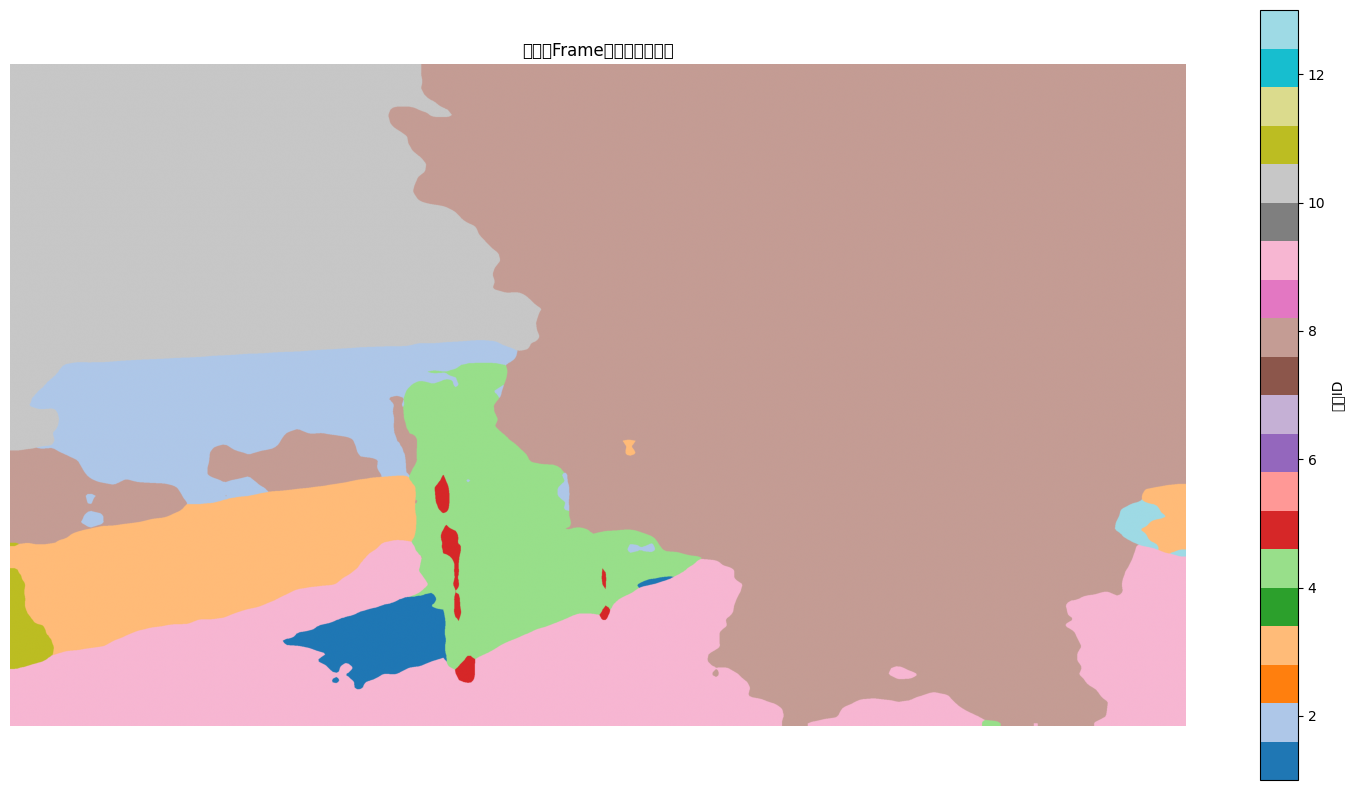

In [ ]:
import matplotlib.pyplot as plt

def visualize_first_frame(filepath):
    """Read and visualize the first frame"""
    with h5py.File(filepath, 'r') as f:
        first_frame = f['segmentation'][0]
        
        # Create image
        plt.figure(figsize=(15, 8))
        plt.imshow(first_frame, cmap='tab20')  # Use a colormap suitable for segmentation
        plt.colorbar(label='Class ID')
        plt.title('Semantic Segmentation Result of the First Frame')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig('first_frame_segmentation.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        return first_frame

# Visualization
frame_0 = visualize_first_frame(file_path)